In [202]:
import pandas as pd
import numpy as np

In [203]:
df = pd.read_csv("C:/Users/Admin/Desktop/Sharvari/Internship/Thiranex/Task 2/customer_behavior_data.csv")
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


# STEP 1: Data Cleaning & Preparation

In [204]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [205]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  17049 non-null  object        
 1   Customer_ID               17049 non-null  object        
 2   Date                      17049 non-null  datetime64[ns]
 3   Age                       17049 non-null  int64         
 4   Gender                    17049 non-null  object        
 5   City                      17049 non-null  object        
 6   Product_Category          17049 non-null  object        
 7   Unit_Price                17049 non-null  float64       
 8   Quantity                  17049 non-null  int64         
 9   Discount_Amount           17049 non-null  float64       
 10  Total_Amount              17049 non-null  float64       
 11  Payment_Method            17049 non-null  object        
 12  Device_Type       

In [206]:
df.duplicated().sum()
df = df.drop_duplicates()

In [207]:
# derived columns
df['Calculated_Total'] = df['Unit_Price'] * df['Quantity'] - df['Discount_Amount']
df['Difference'] = df['Total_Amount'] - df['Calculated_Total']

In [208]:
#Encode Categorical Variables (for later use)
# Gender encoding
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1, 'Other': 2})

# Returning customer
df['Is_Returning_Customer'] = df['Is_Returning_Customer'].astype(int)

In [209]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  17049 non-null  object        
 1   Customer_ID               17049 non-null  object        
 2   Date                      17049 non-null  datetime64[ns]
 3   Age                       17049 non-null  int64         
 4   Gender                    17049 non-null  int64         
 5   City                      17049 non-null  object        
 6   Product_Category          17049 non-null  object        
 7   Unit_Price                17049 non-null  float64       
 8   Quantity                  17049 non-null  int64         
 9   Discount_Amount           17049 non-null  float64       
 10  Total_Amount              17049 non-null  float64       
 11  Payment_Method            17049 non-null  object        
 12  Device_Type       

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Calculated_Total,Difference
0,ORD_000001-1,CUST_00001,2023-05-29,40,0,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,1,13,4,29.18,0.000000e+00
1,ORD_000001-2,CUST_00001,2023-10-12,40,0,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,1,6,2,506.35,5.684342e-14
2,ORD_000001-3,CUST_00001,2023-12-05,40,0,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,1,9,4,1664.10,0.000000e+00
3,ORD_000002-1,CUST_00002,2023-05-11,33,0,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,1,4,4,275.45,0.000000e+00
4,ORD_000002-2,CUST_00002,2023-06-16,33,0,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,1,6,4,534.45,0.000000e+00


# STEP 2: Feature Engineering

In [210]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Reference date for Recency
reference_date = df['Date'].max() + pd.Timedelta(days=1)

# Convert boolean to numeric
df['Is_Returning_Customer'] = df['Is_Returning_Customer'].astype(int)


# Define mode function (for categorical)
def mode_func(x):
    return x.mode()[0] if not x.mode().empty else np.nan

# Group by Customer_ID
customer_df = df.groupby('Customer_ID').agg({
    # 💰 VALUE FEATURES
    'Total_Amount': ['sum', 'mean'],
    'Quantity': 'sum',
    # 🔁 FREQUENCY FEATURES
    'Order_ID': 'nunique',
    # ⏱ RECENCY
    'Date': lambda x: (reference_date - x.max()).days,
    # 🧠 BEHAVIORAL FEATURES
    'Session_Duration_Minutes': 'mean',
    'Pages_Viewed': 'mean',
    'Device_Type': mode_func,
    # 🎯 LOYALTY
    'Is_Returning_Customer': 'mean',
    # ⭐ EXPERIENCE
    'Customer_Rating': 'mean',
    'Delivery_Time_Days': 'mean',
    # 👤 DEMOGRAPHICS
    'Age': 'first',
    'Gender': mode_func,
    'City': mode_func
})

# Flatten column names
customer_df.columns = [
    'Total_Spend',
    'Avg_Order_Value',
    'Total_Quantity',
    'Number_of_Orders',
    'Recency',
    'Avg_Session_Duration',
    'Avg_Pages_Viewed',
    'Preferred_Device',
    'Returning_Rate',
    'Avg_Customer_Rating',
    'Avg_Delivery_Time',
    'Age',
    'Gender',
    'City'
]

# Reset index
customer_df = customer_df.reset_index()

# Purchase Frequency (orders per day)
customer_df['Purchase_Frequency'] = (
    customer_df['Number_of_Orders'] /
    (df['Date'].max() - df['Date'].min()).days
)

# Final Output
print(customer_df.head())
print(customer_df.shape)

  Customer_ID  Total_Spend  Avg_Order_Value  Total_Quantity  Number_of_Orders  \
0  CUST_00001      2199.63       733.210000               7                 3   
1  CUST_00002       809.90       404.950000               8                 2   
2  CUST_00003      3030.81      1515.405000               7                 2   
3  CUST_00004       383.22       383.220000               5                 1   
4  CUST_00005      2422.73       807.576667               8                 3   

   Recency  Avg_Session_Duration  Avg_Pages_Viewed Preferred_Device  \
0      112             14.333333          9.000000           Mobile   
1      284             15.000000         10.000000          Desktop   
2       83             10.500000          8.500000          Desktop   
3       42             16.000000         15.000000          Desktop   
4      279             12.666667          9.333333           Mobile   

   Returning_Rate  Avg_Customer_Rating  Avg_Delivery_Time  Age  Gender  \
0        1.0

# STEP 3: Feature Selection

In [211]:
# 1. Copy dataset
features_df = customer_df.copy()

# 2. Drop non-useful columns
# Customer_ID → identifier (not useful for clustering)
features_df = features_df.drop(columns=['Customer_ID'])

# 3. Select numerical features
numeric_features = [
    'Total_Spend',
    'Avg_Order_Value',
    'Total_Quantity',
    'Number_of_Orders',
    'Recency',
    'Avg_Session_Duration',
    'Avg_Pages_Viewed',
    'Returning_Rate',
    'Avg_Customer_Rating',
    'Avg_Delivery_Time',
    'Age',
    'Purchase_Frequency'
]

# 4. Select categorical features
categorical_features = [
    'Preferred_Device',
    'Gender',
    'City'
]

# 5. Create final feature dataset
selected_df = features_df[numeric_features + categorical_features]

# 6. Handle missing values (important)
# Numeric → fill with median
for col in numeric_features:
    selected_df[col].fillna(selected_df[col].median(), inplace=True)

# Categorical → fill with mode
for col in categorical_features:
    selected_df[col].fillna(selected_df[col].mode()[0], inplace=True)

# 7. Check final dataset
print(selected_df.head())
#print(selected_df.shape)

   Total_Spend  Avg_Order_Value  Total_Quantity  Number_of_Orders  Recency  \
0      2199.63       733.210000               7                 3      112   
1       809.90       404.950000               8                 2      284   
2      3030.81      1515.405000               7                 2       83   
3       383.22       383.220000               5                 1       42   
4      2422.73       807.576667               8                 3      279   

   Avg_Session_Duration  Avg_Pages_Viewed  Returning_Rate  \
0             14.333333          9.000000        1.000000   
1             15.000000         10.000000        1.000000   
2             10.500000          8.500000        0.500000   
3             16.000000         15.000000        0.000000   
4             12.666667          9.333333        0.666667   

   Avg_Customer_Rating  Avg_Delivery_Time  Age  Purchase_Frequency  \
0             3.333333           9.333333   40            0.006682   
1             4.000000  

C:\Users\Admin\AppData\Local\Temp\ipykernel_19196\1701266432.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  selected_df[col].fillna(selected_df[col].median(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19196\1701266432.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df[col].fillna(selected_df[col].median(), i

# STEP 4: Apply Clustering Algorithm

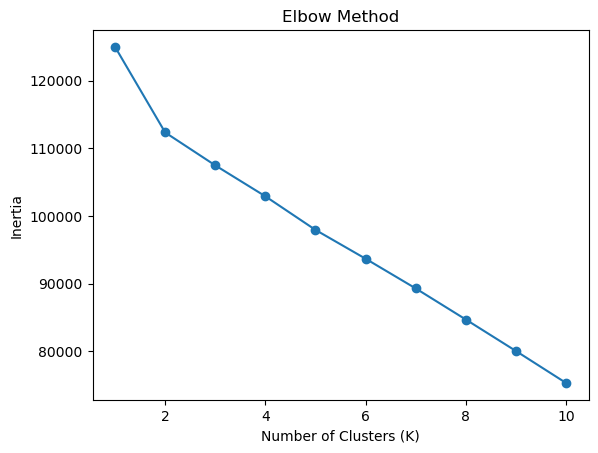

In [212]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Encode categorical features
encoded_df = pd.get_dummies(selected_df, columns=[
    'Preferred_Device',
    'Gender',
    'City'
], drop_first=True)

# 2. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(encoded_df)

# 3. Find optimal K (Elbow Method)
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [213]:
# 4. Apply K-Means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)

# 5. Add cluster labels
selected_df['Cluster'] = clusters

# 6. View results
print(selected_df.head())
print(selected_df['Cluster'].value_counts())

   Total_Spend  Avg_Order_Value  Total_Quantity  Number_of_Orders  Recency  \
0      2199.63       733.210000               7                 3      112   
1       809.90       404.950000               8                 2      284   
2      3030.81      1515.405000               7                 2       83   
3       383.22       383.220000               5                 1       42   
4      2422.73       807.576667               8                 3      279   

   Avg_Session_Duration  Avg_Pages_Viewed  Returning_Rate  \
0             14.333333          9.000000        1.000000   
1             15.000000         10.000000        1.000000   
2             10.500000          8.500000        0.500000   
3             16.000000         15.000000        0.000000   
4             12.666667          9.333333        0.666667   

   Avg_Customer_Rating  Avg_Delivery_Time  Age  Purchase_Frequency  \
0             3.333333           9.333333   40            0.006682   
1             4.000000  

C:\Users\Admin\AppData\Local\Temp\ipykernel_19196\2819038779.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['Cluster'] = clusters


# STEP 5: Analyze Clusters

In [214]:
# 1. Cluster Summary (numeric)
cluster_summary = selected_df.groupby('Cluster').mean(numeric_only=True)
'''print("Cluster Summary (Average Values):")
print(cluster_summary)'''

# 2. Categorical Analysis
device_summary = selected_df.groupby('Cluster')['Preferred_Device'].agg(lambda x: x.mode()[0])
gender_summary = selected_df.groupby('Cluster')['Gender'].agg(lambda x: x.mode()[0])
city_summary = selected_df.groupby('Cluster')['City'].agg(lambda x: x.mode()[0])

'''print("\nMost Common Device per Cluster:")
print(device_summary)

print("\nMost Common Gender per Cluster:")
print(gender_summary)

print("\nMost Common City per Cluster:")
print(city_summary)'''

# 3. Cluster Size
cluster_size = selected_df['Cluster'].value_counts().sort_index()
print("\nCluster Size:")
#print(cluster_size)

# 4. Percentage Distribution
cluster_percent = (cluster_size / len(selected_df)) * 100
#print("\nCluster Percentage:")
#print(cluster_percent)

# 5. Combine everything
cluster_profile = cluster_summary.copy()

cluster_profile['Most_Common_Device'] = device_summary
cluster_profile['Most_Common_Gender'] = gender_summary
cluster_profile['Most_Common_City'] = city_summary
cluster_profile['Cluster_Size'] = cluster_size
cluster_profile['Cluster_%'] = cluster_percent

print("\nFinal Cluster Profile:")
print(cluster_profile)


Cluster Size:

Final Cluster Profile:
         Total_Spend  Avg_Order_Value  Total_Quantity  Number_of_Orders  \
Cluster                                                                   
0        5450.442329      1612.248423       10.753425          3.561644   
1        9094.246966      1621.845897       19.031601          6.171348   
2        2406.783506      1109.685853        6.695689          2.284042   

            Recency  Avg_Session_Duration  Avg_Pages_Viewed  Returning_Rate  \
Cluster                                                                       
0        134.301370             14.523282          9.140753        0.826750   
1         60.297753             14.499598          9.025693        0.938204   
2        152.130745             14.574998          8.974912        0.776230   

         Avg_Customer_Rating  Avg_Delivery_Time        Age  \
Cluster                                                      
0                   3.827691           6.812264  33.438356   
1  

# STEP 6: Analyze Clusters

In [215]:
import pandas as pd
import numpy as np

# 1. Create robust numeric summary
persona_df = selected_df.groupby('Cluster').agg({
    'Total_Spend': ['mean', 'median'],
    'Number_of_Orders': ['mean'],
    'Recency': ['mean'],
    'Avg_Session_Duration': ['mean'],
    'Avg_Pages_Viewed': ['mean'],
    'Avg_Customer_Rating': ['mean'],
    'Avg_Delivery_Time': ['mean'],
    'Age': ['mean']
})

# Flatten column names
persona_df.columns = ['_'.join(col) for col in persona_df.columns]

# 2. Add categorical insights
persona_df['Preferred_Device'] = selected_df.groupby('Cluster')['Preferred_Device'].agg(lambda x: x.mode()[0])
persona_df['Gender'] = selected_df.groupby('Cluster')['Gender'].agg(lambda x: x.mode()[0])
persona_df['City'] = selected_df.groupby('Cluster')['City'].agg(lambda x: x.mode()[0])

# 3. Add size & percentage
cluster_size = selected_df['Cluster'].value_counts().sort_index()
persona_df['Cluster_Size'] = cluster_size
persona_df['Cluster_%'] = (cluster_size / len(selected_df)) * 100

# 4. Data-driven Persona Naming
def assign_persona(row):
    if row['Total_Spend_mean'] > selected_df['Total_Spend'].median() and row['Number_of_Orders_mean'] > selected_df['Number_of_Orders'].median():
        return "Premium Loyal Customers"
    elif row['Avg_Session_Duration_mean'] > selected_df['Avg_Session_Duration'].median() and row['Total_Spend_mean'] < selected_df['Total_Spend'].median():
        return "Window Shoppers"
    elif row['Recency_mean'] > selected_df['Recency'].median():
        return "At-Risk Customers"
    else:
        return "Budget Customers"
persona_df['Persona'] = persona_df.apply(assign_persona, axis=1)

# 5. Map personas back
persona_map = persona_df['Persona'].to_dict()
selected_df['Persona'] = selected_df['Cluster'].map(persona_map)
selected_df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_19196\3409167314.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['Persona'] = selected_df['Cluster'].map(persona_map)


,Total_Spend,Avg_Order_Value,Total_Quantity,Number_of_Orders,Recency,Avg_Session_Duration,Avg_Pages_Viewed,Returning_Rate,Avg_Customer_Rating,Avg_Delivery_Time,Age,Purchase_Frequency,Preferred_Device,Gender,City,Cluster,Persona
0,2199.63,733.210000,7,3,112,14.333333,9.000000,1.000000,3.333333,9.333333,40,0.006682,Mobile,0,Ankara,2,Window Shoppers
1,809.90,404.950000,8,2,284,15.000000,10.000000,1.000000,4.000000,5.000000,33,0.004454,Desktop,0,Istanbul,2,Window Shoppers
2,3030.81,1515.405000,7,2,83,10.500000,8.500000,0.500000,3.500000,6.000000,42,0.004454,Desktop,0,Konya,2,Window Shoppers
3,383.22,383.220000,5,1,42,16.000000,15.000000,0.000000,5.000000,4.000000,53,0.002227,Desktop,0,Izmir,2,Window Shoppers
4,2422.73,807.576667,8,3,279,12.666667,9.333333,0.666667,3.666667,5.666667,32,0.006682,Mobile,0,Ankara,2,Window Shoppers


# Visualization 

In [216]:
import matplotlib.pyplot as plt

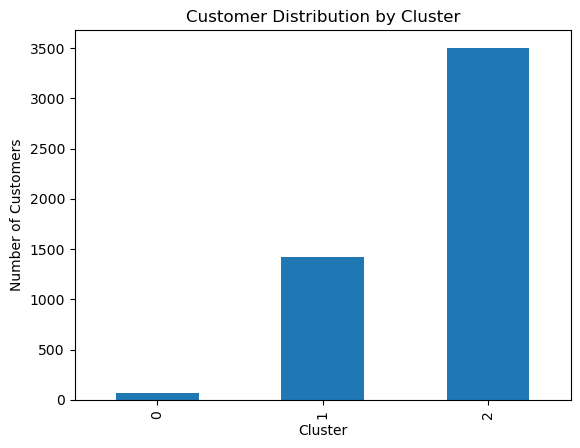

In [217]:
# Cluster Distribution (How many customers in each segment)
cluster_counts = selected_df['Cluster'].value_counts().sort_index()
cluster_counts.plot(kind='bar')
plt.title('Customer Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

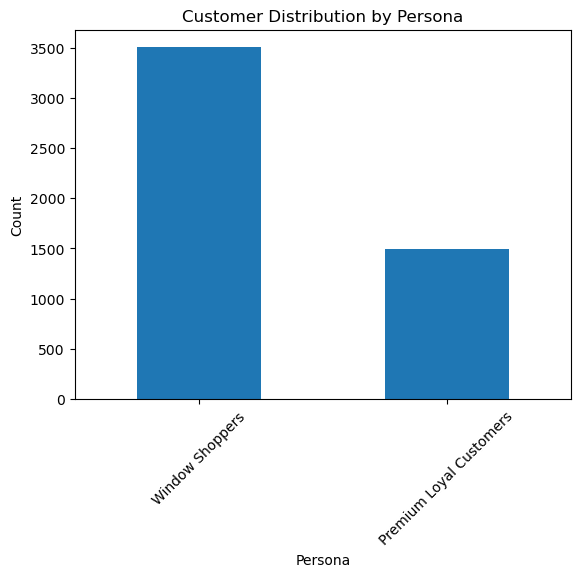

In [218]:
# Personas Distribution
persona_counts = selected_df['Persona'].value_counts()
persona_counts.plot(kind='bar')
plt.title('Customer Distribution by Persona')
plt.xlabel('Persona')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

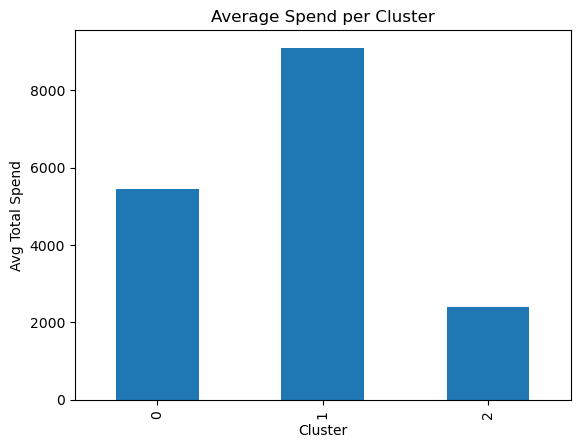

In [219]:
# Average Spend per Cluster
selected_df.groupby('Cluster')['Total_Spend'].mean().plot(kind='bar')
plt.title('Average Spend per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Avg Total Spend')
plt.show()

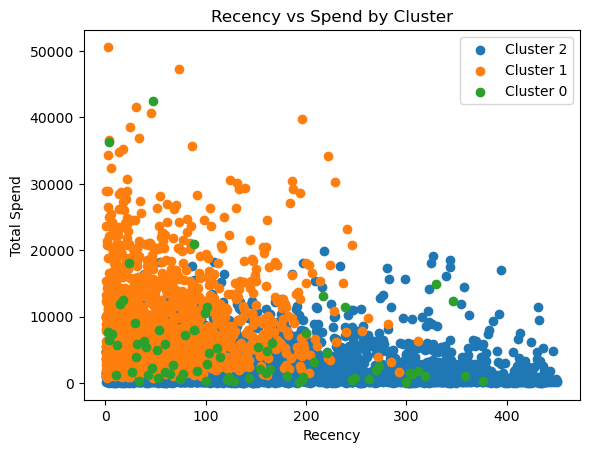

In [220]:
# Recency vs Spend (Cluster Scatter)
plt.figure()
for cluster in selected_df['Cluster'].unique():
    subset = selected_df[selected_df['Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Total_Spend'], label=f'Cluster {cluster}')
plt.xlabel('Recency')
plt.ylabel('Total Spend')
plt.title('Recency vs Spend by Cluster')
plt.legend()
plt.show()

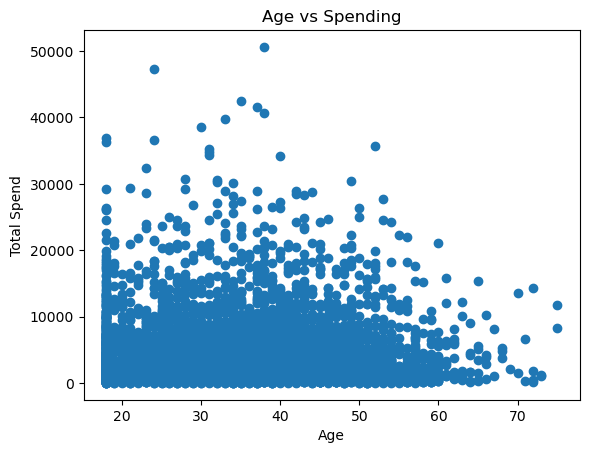

In [221]:
# Age vs Spend
plt.figure()
plt.scatter(selected_df['Age'], selected_df['Total_Spend'])
plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('Age vs Spending')
plt.show()

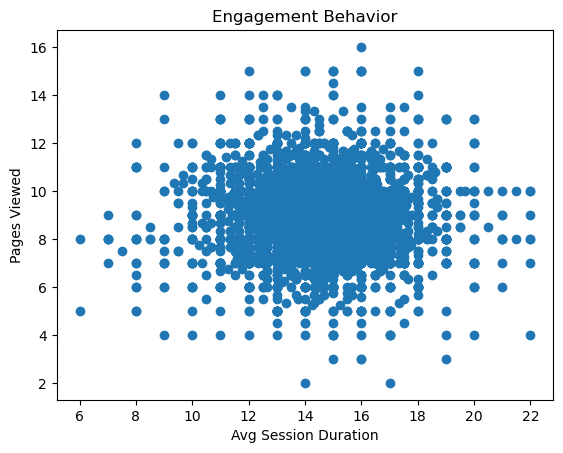

In [222]:
# Engagement Analysis (Session vs Pages)
plt.figure()
plt.scatter(selected_df['Avg_Session_Duration'], selected_df['Avg_Pages_Viewed'])
plt.xlabel('Avg Session Duration')
plt.ylabel('Pages Viewed')
plt.title('Engagement Behavior')
plt.show()

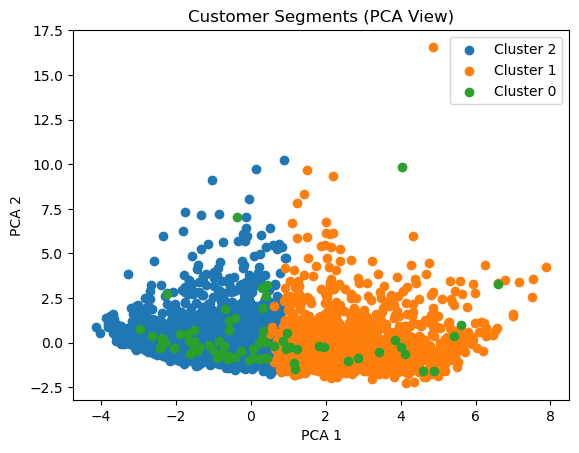

In [223]:
# PCA Visualization (Best for Clusters 🔥)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare data
encoded_df = pd.get_dummies(selected_df.drop(columns=['Cluster', 'Persona'], errors='ignore'), drop_first=True)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(encoded_df)

# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Plot
plt.figure()
for cluster in selected_df['Cluster'].unique():
    plt.scatter(
        pca_data[selected_df['Cluster'] == cluster, 0],
        pca_data[selected_df['Cluster'] == cluster, 1],
        label=f'Cluster {cluster}'
    )

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Customer Segments (PCA View)')
plt.legend()
plt.show()

In [224]:
print("\n🔍 Insights:")
for i, row in cluster_profile.iterrows():
    print(f"\nCluster {i}:")
    print(f"- Avg Spend: {row['Total_Spend']:.2f}")
    print(f"- Orders: {row['Number_of_Orders']:.2f}")
    print(f"- Recency: {row['Recency']:.2f}")


🔍 Insights:

Cluster 0:
- Avg Spend: 5450.44
- Orders: 3.56
- Recency: 134.30

Cluster 1:
- Avg Spend: 9094.25
- Orders: 6.17
- Recency: 60.30

Cluster 2:
- Avg Spend: 2406.78
- Orders: 2.28
- Recency: 152.13
